# Advanced Frog Species Prediction Model
## Using TerraClimate Variables for Binary Classification

This notebook builds a machine learning classification model to predict frog species presence based on TerraClimate climate variables. The model uses advanced feature engineering, multiple algorithms, and proper cross-validation to achieve high F1 Score performance.

## Section 1: Import Required Libraries

Import necessary libraries for data science, machine learning, and data manipulation.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib
import os

# Machine Learning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Gradient boosting libraries
import lightgbm as lgb
import xgboost as xgb
import optuna

# For climate data
import xarray as xr
import rasterio

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("All libraries imported successfully!")

All libraries imported successfully!


## Section 2: Load and Explore the Data

Load the training and test datasets from CSV files and understand their structure.

In [2]:
# Load training and test data
train_data = pd.read_csv('Training_Data.csv')
test_data = pd.read_csv('Test.csv')

print("Training Data Shape:", train_data.shape)
print("\nTraining Data Info:")
print(train_data.head())
print("\nTarget Distribution:")
print(train_data['Occurrence Status'].value_counts())
print("\nClass Balance:")
print(train_data['Occurrence Status'].value_counts(normalize=True))

print("\n" + "="*50)
print("Test Data Shape:", test_data.shape)
print("Test Data Info:")
print(test_data.head())

Training Data Shape: (6312, 4)

Training Data Info:
             ID   Latitude   Longitude  Occurrence Status
0  ID_TR_957A5A -34.027900  150.771000                  1
1  ID_TR_55E0AF -34.821595  147.193697                  1
2  ID_TR_7AC931 -36.617759  146.882941                  0
3  ID_TR_7D3CE4 -37.470900  144.744000                  1
4  ID_TR_02F669 -38.400153  145.018560                  1

Target Distribution:
Occurrence Status
1    3792
0    2520
Name: count, dtype: int64

Class Balance:
Occurrence Status
1    0.60076
0    0.39924
Name: proportion, dtype: float64

Test Data Shape: (2000, 3)
Test Data Info:
             ID   Latitude   Longitude
0  ID_TS_54240C -33.121788  150.320746
1  ID_TS_EF9635 -36.592011  148.172262
2  ID_TS_4E63E6 -35.455100  146.693465
3  ID_TS_FDAB8E -33.076261  149.547177
4  ID_TS_E00D49 -35.529729  146.627272


## Section 3: Extract TerraClimate Variables

Define a function to extract TerraClimate climate variables from GeoTIFF files using lat/lon coordinates.

In [3]:
def extract_climate_features(tiff_path, csv_df, band_names):
    """
    Extract ALL climate variables from GeoTIFF file at specified lat/lon locations.
    Reads band_names from band_names.json generated by TerraClimate.ipynb.
    """
    with rasterio.open(tiff_path) as dataset:
        lon = np.linspace(dataset.bounds.left, dataset.bounds.right, dataset.width)
        lat = np.linspace(dataset.bounds.top, dataset.bounds.bottom, dataset.height)

        climate_arrays = {}
        for i, band_name in enumerate(band_names, 1):
            if i > dataset.count:
                print(f"Warning: Band {i} ({band_name}) not available. Skipping.")
                continue
            raster_data = dataset.read(i)
            da = xr.DataArray(
                raster_data,
                coords=[("lat", lat), ("lon", lon)],
                dims=["lat", "lon"]
            )
            climate_arrays[band_name] = da

    extracted = {name: [] for name in climate_arrays}

    for _, row in tqdm(csv_df.iterrows(), total=len(csv_df), desc="Extracting climate data"):
        target_lat, target_lon = row["Latitude"], row["Longitude"]
        for band_name, da in climate_arrays.items():
            try:
                val = da.sel(lat=target_lat, lon=target_lon, method="nearest").values
                extracted[band_name].append(float(val))
            except Exception:
                extracted[band_name].append(np.nan)

    return pd.DataFrame(extracted)


# Load band names from JSON (generated by TerraClimate.ipynb)
tiff_path = 'TerraClimate_output.tiff'
band_names_file = 'band_names.json'

if os.path.exists(tiff_path) and os.path.exists(band_names_file):
    with open(band_names_file) as f:
        band_names = json.load(f)
    print(f"GeoTIFF found with {len(band_names)} bands: {band_names}")

    train_climate = extract_climate_features(tiff_path, train_data, band_names)
    test_climate = extract_climate_features(tiff_path, test_data, band_names)

    print(f"\nTrain climate shape: {train_climate.shape}")
    print(f"Test climate shape:  {test_climate.shape}")
    print(train_climate.describe())
elif os.path.exists(tiff_path):
    # Fallback: no band_names.json — read whatever bands exist
    with rasterio.open(tiff_path) as src:
        n_bands = src.count
    band_names = [f"band_{i}" for i in range(1, n_bands + 1)]
    print(f"No band_names.json found. Reading {n_bands} bands with generic names.")

    train_climate = extract_climate_features(tiff_path, train_data, band_names)
    test_climate = extract_climate_features(tiff_path, test_data, band_names)
else:
    print("ERROR: TerraClimate_output.tiff not found!")
    print("Please run TerraClimate.ipynb first to generate the GeoTIFF.")
    train_climate = pd.DataFrame()
    test_climate = pd.DataFrame()

GeoTIFF found with 28 bands: ['aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std']


Extracting climate data: 100%|██████████| 2000/2000 [00:39<00:00, 50.57it/s]



Train climate shape: (6312, 28)
Test climate shape:  (2000, 28)
        aet_median   def_median  pdsi_median   pet_median   ppt_median  \
count  6312.000000  6312.000000  6312.000000  6312.000000  6312.000000   
mean     42.468949    66.832225    -4.205925   120.981640    47.162722   
std      14.310979    35.670742     0.781642    16.712783    18.748566   
min       9.600000     0.000000    -6.500000    78.599998    10.100000   
25%      33.200001    40.299999    -4.700000   109.074999    34.000000   
50%      42.500000    61.400002    -4.400000   116.099998    45.000000   
75%      51.799999    90.599998    -3.800000   130.199997    59.025000   
max      96.599998   148.400009    -2.300000   164.699997   127.800000   

          q_median  soil_median  srad_median   swe_median  tmax_median  \
count  6312.000000  6312.000000  6312.000000  6312.000000  6312.000000   
mean      2.426061    22.674858   206.006832     0.000111    21.773526   
std       1.285706    31.136363    12.158110  

## Section 4: Preprocess and Engineer Features

Combine climate features with ground truth data, handle missing values, and prepare features for modeling.

In [4]:
def create_combined_dataset(climate_df, ground_df, include_coords=True):
    """Combine climate features with ground truth data, optionally keep lat/lon as features."""
    combined = pd.concat([ground_df.reset_index(drop=True), climate_df.reset_index(drop=True)], axis=1)

    # Fill missing climate values with column median
    numeric_cols = combined.select_dtypes(include=[np.number]).columns
    combined[numeric_cols] = combined[numeric_cols].fillna(combined[numeric_cols].median())

    if not include_coords:
        combined = combined.drop(columns=['Latitude', 'Longitude'], errors='ignore')

    return combined


# Build combined datasets — KEEP lat/lon as features (geographic position is predictive)
if len(train_climate) > 0:
    X_train_combined = create_combined_dataset(train_climate, train_data, include_coords=True)
    X_test_combined = create_combined_dataset(test_climate, test_data, include_coords=True)
else:
    X_train_combined = train_data.copy()
    X_test_combined = test_data.copy()

print("Combined Training Data Shape:", X_train_combined.shape)
print("Columns:", X_train_combined.columns.tolist())

Combined Training Data Shape: (6312, 32)
Columns: ['ID', 'Latitude', 'Longitude', 'Occurrence Status', 'aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std']


In [5]:
# Prepare X and y — include Latitude/Longitude as features, exclude ID and target
exclude_cols = ['ID', 'Occurrence Status']
feature_cols = [c for c in X_train_combined.columns if c not in exclude_cols]

X = X_train_combined[feature_cols].copy()
y = X_train_combined['Occurrence Status'].copy()

test_ids = X_test_combined['ID'].copy()
X_test_final = X_test_combined[feature_cols].copy()

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Training: {X.shape}, Test: {X_test_final.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1")

Features (30): ['Latitude', 'Longitude', 'aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std']
Training: (6312, 30), Test: (2000, 30)
Target distribution:
Occurrence Status
1    3792
0    2520
Name: count, dtype: int64
Imbalance ratio: 0.66:1


## Section 5: Split Data into Training and Validation Sets

Partition the training data into train and validation subsets using stratified split to maintain class balance.

In [6]:
# Stratified train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape},  Val: {X_val.shape}")
print(f"Train dist:\n{y_train.value_counts(normalize=True)}")
print(f"Val dist:\n{y_val.value_counts(normalize=True)}")

Train: (5049, 30),  Val: (1263, 30)
Train dist:
Occurrence Status
1    0.600713
0    0.399287
Name: proportion, dtype: float64
Val dist:
Occurrence Status
1    0.60095
0    0.39905
Name: proportion, dtype: float64


## Section 6: Feature Engineering

Create derived features from climate variables to improve model discrimination.

In [7]:
def engineer_features(df, base_feature_cols):
    """Create derived features from base climate + coordinate columns."""
    out = df.copy()

    # Separate median and std columns
    median_cols = [c for c in base_feature_cols if c.endswith('_median')]
    std_cols = [c for c in base_feature_cols if c.endswith('_std')]
    climate_cols = median_cols if median_cols else [
        c for c in base_feature_cols if c not in ['Latitude', 'Longitude']
    ]

    # 1. Aggregate statistics across all median climate features
    if len(climate_cols) >= 2:
        out['climate_mean'] = out[climate_cols].mean(axis=1)
        out['climate_std'] = out[climate_cols].std(axis=1)
        out['climate_range'] = out[climate_cols].max(axis=1) - out[climate_cols].min(axis=1)
        out['climate_cv'] = out['climate_std'] / (out['climate_mean'].abs() + 1e-8)

    # 2. Key interaction terms (limit to avoid dimensionality explosion)
    if 'Latitude' in out.columns and 'Longitude' in out.columns:
        out['lat_lon_interaction'] = out['Latitude'] * out['Longitude']
        out['lat_abs'] = out['Latitude'].abs()
        # Encode lat/lon cyclically for geographic patterns
        out['lat_sin'] = np.sin(np.radians(out['Latitude']))
        out['lon_sin'] = np.sin(np.radians(out['Longitude']))
        out['lon_cos'] = np.cos(np.radians(out['Longitude']))

    # 3. Ratio of std to median (temporal variability relative to level)
    for mc in median_cols:
        var_base = mc.replace('_median', '')
        sc = f"{var_base}_std"
        if sc in out.columns:
            out[f"{var_base}_cv"] = out[sc] / (out[mc].abs() + 1e-8)

    # 4. Squared terms for top climate variables (non-linear effects)
    for col in climate_cols[:5]:
        out[f"{col}_sq"] = out[col] ** 2

    # Fill any NaN/inf from engineering
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.fillna(out.median(numeric_only=True))

    return out

# Apply feature engineering
X_train_eng = engineer_features(X_train, feature_cols)
X_val_eng = engineer_features(X_val, feature_cols)
X_test_eng = engineer_features(X_test_final, feature_cols)

eng_feature_cols = X_train_eng.columns.tolist()
print(f"Engineered feature count: {len(eng_feature_cols)}")
print(f"Sample features: {eng_feature_cols[:20]}")

Engineered feature count: 58
Sample features: ['Latitude', 'Longitude', 'aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std']


In [8]:
# ============================================================
# OPTUNA HYPERPARAMETER TUNING FOR LightGBM
# ============================================================
print("=" * 60)
print("OPTUNA: Tuning LightGBM with 150 trials (5-fold CV)")
print("=" * 60)

# Impute once for Optuna loop
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_eng), columns=eng_feature_cols
)
X_val_imp = pd.DataFrame(
    imputer.transform(X_val_eng), columns=eng_feature_cols
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'device_type': 'gpu',
    }
    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=-1)
    scores = cross_val_score(model, X_train_imp, y_train, cv=skf, scoring='f1', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', study_name='lgbm_f1')
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"\nBest CV F1:    {study.best_value:.4f}")
print(f"Best params:   {study.best_params}")

lgb_best_params = {**study.best_params, 'device_type': 'gpu'}
print(f"LightGBM device_type: {lgb_best_params['device_type']}")

# Train best LightGBM on full train split
best_lgbm = lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)
best_lgbm.fit(X_train_imp, y_train)

y_pred_lgbm_val = best_lgbm.predict(X_val_imp)
f1_lgbm = f1_score(y_val, y_pred_lgbm_val)
print(f"LightGBM Val F1: {f1_lgbm:.4f}")
print(classification_report(y_val, y_pred_lgbm_val, target_names=['No Frog', 'Frog']))

OPTUNA: Tuning LightGBM with 150 trials (5-fold CV)


Best trial: 129. Best value: 0.829759: 100%|██████████| 150/150 [2:16:25<00:00, 54.57s/it]



Best CV F1:    0.8298
Best params:   {'n_estimators': 804, 'learning_rate': 0.006194257902261912, 'max_depth': 7, 'num_leaves': 74, 'min_child_samples': 17, 'subsample': 0.8594286445072048, 'colsample_bytree': 0.48874335510327876, 'reg_alpha': 0.007460187292741815, 'reg_lambda': 0.17566620185000603, 'scale_pos_weight': 1.3366471247257135}
LightGBM device_type: gpu
LightGBM Val F1: 0.8399
              precision    recall  f1-score   support

     No Frog       0.82      0.62      0.70       504
        Frog       0.78      0.91      0.84       759

    accuracy                           0.79      1263
   macro avg       0.80      0.76      0.77      1263
weighted avg       0.80      0.79      0.78      1263



In [9]:
# ============================================================
# OPTUNA HYPERPARAMETER TUNING FOR XGBoost
# ============================================================
print("=" * 60)
print("OPTUNA: Tuning XGBoost with 150 trials (5-fold CV)")
print("=" * 60)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
    }
    model = xgb.XGBClassifier(**params, random_state=42, verbosity=0, n_jobs=-1,
                               eval_metric='logloss')
    scores = cross_val_score(model, X_train_imp, y_train, cv=skf, scoring='f1', n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize', study_name='xgb_f1')
study_xgb.optimize(objective_xgb, n_trials=150, show_progress_bar=True)

print(f"\nBest CV F1:    {study_xgb.best_value:.4f}")
print(f"Best params:   {study_xgb.best_params}")

best_xgb = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0,
                               n_jobs=-1, eval_metric='logloss')
best_xgb.fit(X_train_imp, y_train)

y_pred_xgb_val = best_xgb.predict(X_val_imp)
f1_xgb = f1_score(y_val, y_pred_xgb_val)
print(f"XGBoost Val F1: {f1_xgb:.4f}")
print(classification_report(y_val, y_pred_xgb_val, target_names=['No Frog', 'Frog']))

OPTUNA: Tuning XGBoost with 150 trials (5-fold CV)


Best trial: 133. Best value: 0.830741: 100%|██████████| 150/150 [33:04<00:00, 13.23s/it]



Best CV F1:    0.8307
Best params:   {'n_estimators': 1039, 'learning_rate': 0.005020629508984338, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.7122874283975021, 'colsample_bytree': 0.6363538084186589, 'reg_alpha': 1.2448628725854954e-06, 'reg_lambda': 6.22102444922852e-05, 'scale_pos_weight': 1.2519448395719834, 'gamma': 1.5046700930704775e-07}
XGBoost Val F1: 0.8457
              precision    recall  f1-score   support

     No Frog       0.82      0.64      0.72       504
        Frog       0.79      0.91      0.85       759

    accuracy                           0.80      1263
   macro avg       0.81      0.77      0.78      1263
weighted avg       0.80      0.80      0.80      1263



In [10]:
# ============================================================
# RANDOM FOREST (for ensemble diversity)
# ============================================================
print("=" * 60)
print("Training Random Forest for stacking diversity")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=500, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train_imp, y_train)

y_pred_rf_val = rf_model.predict(X_val_imp)
f1_rf = f1_score(y_val, y_pred_rf_val)
print(f"Random Forest Val F1: {f1_rf:.4f}")

print("\n" + "=" * 60)
print("INDIVIDUAL MODEL COMPARISON")
print("=" * 60)
print(f"LightGBM:      {f1_lgbm:.4f}")
print(f"XGBoost:       {f1_xgb:.4f}")
print(f"Random Forest: {f1_rf:.4f}")

Training Random Forest for stacking diversity
Random Forest Val F1: 0.8236

INDIVIDUAL MODEL COMPARISON
LightGBM:      0.8399
XGBoost:       0.8457
Random Forest: 0.8236


In [11]:
# ============================================================
# STACKING ENSEMBLE
# ============================================================
print("=" * 60)
print("STACKING ENSEMBLE: LightGBM + XGBoost + RF → LogisticRegression meta")
print("=" * 60)

stacking_model = StackingClassifier(
    estimators=[
        ('lgbm', lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0,
                                     n_jobs=-1, eval_metric='logloss')),
        ('rf', RandomForestClassifier(
            n_estimators=500, max_depth=15, min_samples_split=5,
            min_samples_leaf=2, class_weight='balanced',
            random_state=42, n_jobs=-1
        )),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

print("Fitting stacking ensemble (5-fold internal CV)...")
stacking_model.fit(X_train_imp, y_train)
print("Done!")

y_pred_stack_val = stacking_model.predict(X_val_imp)
f1_stack = f1_score(y_val, y_pred_stack_val)
print(f"\nStacking Ensemble Val F1: {f1_stack:.4f}")
print(classification_report(y_val, y_pred_stack_val, target_names=['No Frog', 'Frog']))

print("\n" + "=" * 60)
print("ALL MODELS COMPARISON")
print("=" * 60)
print(f"LightGBM:         {f1_lgbm:.4f}")
print(f"XGBoost:          {f1_xgb:.4f}")
print(f"Random Forest:    {f1_rf:.4f}")
print(f"Stacking:         {f1_stack:.4f}")

STACKING ENSEMBLE: LightGBM + XGBoost + RF → LogisticRegression meta
Fitting stacking ensemble (5-fold internal CV)...
Done!

Stacking Ensemble Val F1: 0.8389
              precision    recall  f1-score   support

     No Frog       0.79      0.67      0.72       504
        Frog       0.80      0.88      0.84       759

    accuracy                           0.80      1263
   macro avg       0.79      0.78      0.78      1263
weighted avg       0.80      0.80      0.79      1263


ALL MODELS COMPARISON
LightGBM:         0.8399
XGBoost:          0.8457
Random Forest:    0.8236
Stacking:         0.8389


THRESHOLD TUNING via 5-fold Cross-Validation
Best model for threshold tuning: XGBoost (Val F1=0.8457)

Running 5-fold CV to find optimal threshold...
  Fold 1: best threshold=0.49, F1=0.8278
  Fold 2: best threshold=0.51, F1=0.8277
  Fold 3: best threshold=0.50, F1=0.8282
  Fold 4: best threshold=0.48, F1=0.8311
  Fold 5: best threshold=0.49, F1=0.8377

CV-averaged optimal threshold: 0.494
Val F1 at optimal threshold (0.494): 0.8449
Val F1 at default threshold (0.50):             0.8457
Improvement: -0.0008


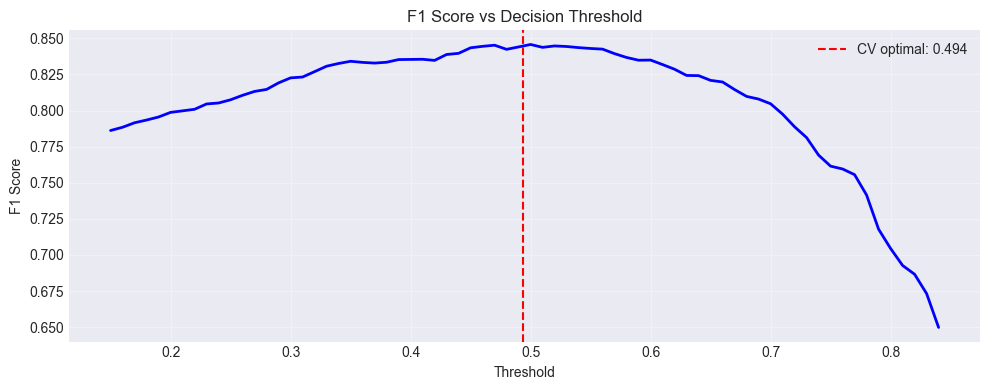

In [12]:
# ============================================================
# CV-BASED THRESHOLD TUNING (robust, not overfit to single split)
# ============================================================
print("=" * 60)
print("THRESHOLD TUNING via 5-fold Cross-Validation")
print("=" * 60)

# Pick best individual model for threshold tuning
model_candidates = {
    'LightGBM': best_lgbm,
    'XGBoost': best_xgb,
    'Stacking': stacking_model,
}
val_scores = {'LightGBM': f1_lgbm, 'XGBoost': f1_xgb, 'Stacking': f1_stack}
best_name = max(val_scores, key=val_scores.get)
best_model = model_candidates[best_name]
print(f"Best model for threshold tuning: {best_name} (Val F1={val_scores[best_name]:.4f})")

# Get probabilities on validation set
if hasattr(best_model, 'predict_proba'):
    y_proba_val = best_model.predict_proba(X_val_imp)[:, 1]
else:
    y_proba_val = best_model.decision_function(X_val_imp)

# Also do CV threshold tuning on full training set for robustness
print("\nRunning 5-fold CV to find optimal threshold...")
cv_thresholds = []
skf_thresh = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf_thresh.split(X_train_imp, y_train)):
    X_tr_fold = X_train_imp.iloc[train_idx]
    y_tr_fold = y_train.iloc[train_idx]
    X_va_fold = X_train_imp.iloc[val_idx]
    y_va_fold = y_train.iloc[val_idx]

    # Clone and fit best model type on this fold
    if best_name == 'LightGBM':
        fold_model = lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)
    elif best_name == 'XGBoost':
        fold_model = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0,
                                        n_jobs=-1, eval_metric='logloss')
    else:
        # For stacking, just use LightGBM for threshold search (stacking is expensive)
        fold_model = lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)

    fold_model.fit(X_tr_fold, y_tr_fold)
    fold_proba = fold_model.predict_proba(X_va_fold)[:, 1]

    # Find best threshold for this fold
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.20, 0.80, 0.01):
        f1_t = f1_score(y_va_fold, (fold_proba >= t).astype(int))
        if f1_t > best_f1:
            best_t, best_f1 = t, f1_t
    cv_thresholds.append(best_t)
    print(f"  Fold {fold+1}: best threshold={best_t:.2f}, F1={best_f1:.4f}")

optimal_threshold = np.mean(cv_thresholds)
print(f"\nCV-averaged optimal threshold: {optimal_threshold:.3f}")

# Apply to held-out validation set
y_pred_optimal = (y_proba_val >= optimal_threshold).astype(int)
f1_optimal = f1_score(y_val, y_pred_optimal)
print(f"Val F1 at optimal threshold ({optimal_threshold:.3f}): {f1_optimal:.4f}")
print(f"Val F1 at default threshold (0.50):             {val_scores[best_name]:.4f}")
print(f"Improvement: {f1_optimal - val_scores[best_name]:.4f}")

# Plot threshold curve
thresholds = np.arange(0.15, 0.85, 0.01)
f1s = [f1_score(y_val, (y_proba_val >= t).astype(int)) for t in thresholds]
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1s, 'b-', linewidth=2)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'CV optimal: {optimal_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Decision Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE (LightGBM)

Top 25 features:
            feature  importance
           pdsi_std        1494
            pdsi_cv        1273
             ws_std        1194
           srad_std        1122
             pet_cv        1120
             aet_cv        1085
               q_cv         976
             ppt_cv         960
              ws_cv         893
            pet_std         885
         vap_median         885
            soil_cv         872
            srad_cv         819
lat_lon_interaction         804
          Longitude         784
            def_std         766
             vap_cv         762
            aet_std         732
       climate_mean         731
           soil_std         713
             def_cv         677
            tmin_cv         672
             vpd_cv         661
        srad_median         659
         pet_median         657


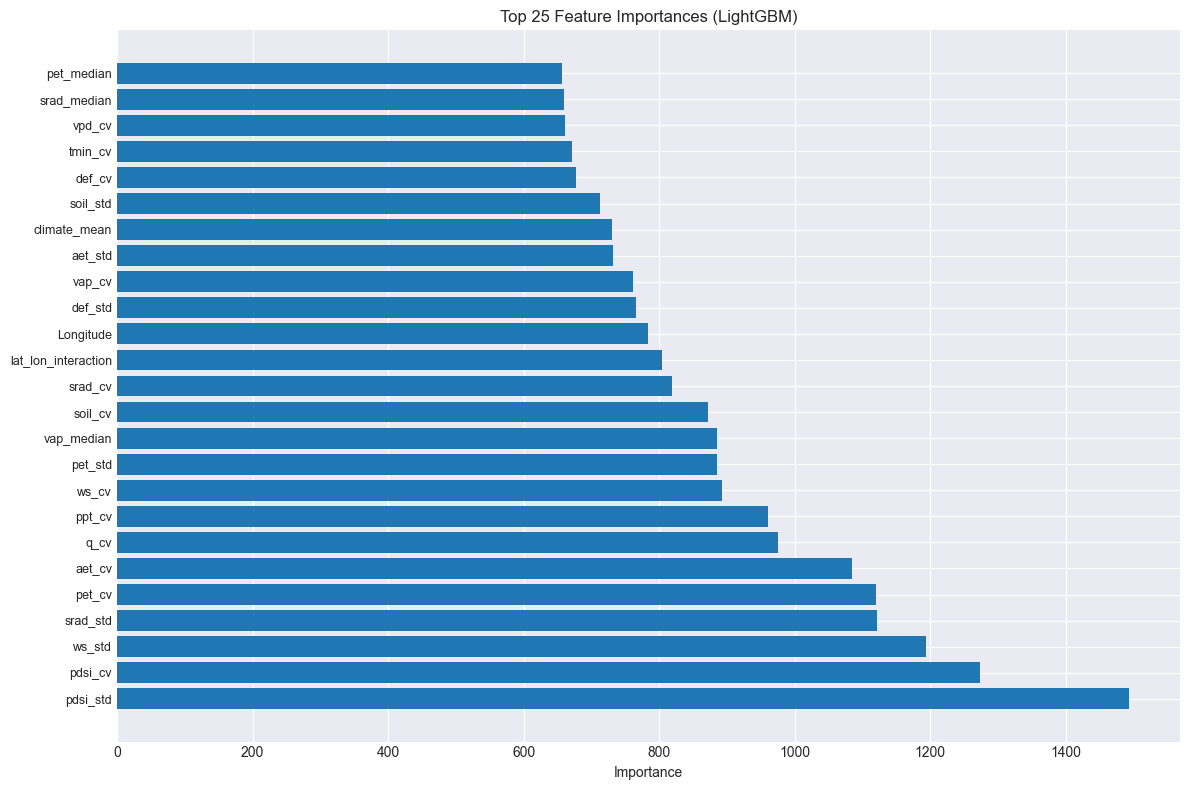

In [13]:
# ============================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================
print("=" * 60)
print("FEATURE IMPORTANCE (LightGBM)")
print("=" * 60)

importance_df = pd.DataFrame({
    'feature': eng_feature_cols,
    'importance': best_lgbm.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 25 features:")
print(importance_df.head(25).to_string(index=False))

plt.figure(figsize=(12, 8))
top_n = min(25, len(importance_df))
plt.barh(range(top_n), importance_df['importance'].head(top_n).values)
plt.yticks(range(top_n), importance_df['feature'].head(top_n).values, fontsize=9)
plt.xlabel('Importance')
plt.title('Top 25 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# RETRAIN BEST MODEL ON FULL TRAINING DATA (train + val)
# ============================================================
print("=" * 60)
print("RETRAIN BEST MODEL ON 100% OF TRAINING DATA")
print("=" * 60)

# Combine train + val for final model
X_full = pd.concat([X_train_eng, X_val_eng], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

X_full_imp = pd.DataFrame(
    imputer.fit_transform(X_full), columns=eng_feature_cols
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test_eng), columns=eng_feature_cols
)

# Retrain LightGBM with best params on full data
print(f"Retraining {best_name} on {X_full_imp.shape[0]} samples...")
if best_name == 'LightGBM':
    final_model = lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)
elif best_name == 'XGBoost':
    final_model = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0,
                                     n_jobs=-1, eval_metric='logloss')
else:
    # Stacking is best — retrain it
    final_model = StackingClassifier(
        estimators=[
            ('lgbm', lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)),
            ('xgb', xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0,
                                         n_jobs=-1, eval_metric='logloss')),
            ('rf', RandomForestClassifier(
                n_estimators=500, max_depth=15, min_samples_split=5,
                min_samples_leaf=2, class_weight='balanced',
                random_state=42, n_jobs=-1
            )),
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=5, n_jobs=-1, passthrough=False
    )

final_model.fit(X_full_imp, y_full)
print("Final model trained on full data!")

# Quick sanity check with CV on full data
print("\n5-fold CV on full training data:")
cv_scores = cross_val_score(final_model, X_full_imp, y_full, cv=5, scoring='f1', n_jobs=-1)
print(f"CV F1 scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

RETRAIN BEST MODEL ON 100% OF TRAINING DATA
Retraining XGBoost on 6312 samples...
Final model trained on full data!

5-fold CV on full training data:
CV F1 scores: [0.82142857 0.82510664 0.83467492 0.83607556 0.84171779]
Mean: 0.8318 ± 0.0074


In [15]:
# ============================================================
# GENERATE TEST PREDICTIONS AND SUBMISSION FILE
# ============================================================
print("=" * 60)
print("GENERATING FINAL SUBMISSION")
print("=" * 60)

# Get probability predictions on test set
y_proba_test = final_model.predict_proba(X_test_imp)[:, 1]

# Apply CV-optimized threshold
y_pred_test = (y_proba_test >= optimal_threshold).astype(int)

print(f"Threshold used: {optimal_threshold:.3f}")
print(f"Prediction distribution:")
print(f"  No Frog (0): {np.sum(y_pred_test == 0)}")
print(f"  Frog (1):    {np.sum(y_pred_test == 1)}")

# Create submission DataFrame
submission = pd.DataFrame({
    'ID': test_ids.values,
    'Target': y_pred_test
})

print(f"\nSubmission shape: {submission.shape}")
print(submission.head(10))

# Save submission
submission_file = f'Submission_Final_{best_name}_t{optimal_threshold:.2f}.csv'
submission.to_csv(submission_file, index=False)
print(f"\n✓ Submission saved: {submission_file}")

# Also save with standard name
submission.to_csv('Predicted_Data.csv', index=False)
print(f"✓ Also saved as: Predicted_Data.csv")

GENERATING FINAL SUBMISSION
Threshold used: 0.494
Prediction distribution:
  No Frog (0): 633
  Frog (1):    1367

Submission shape: (2000, 2)
             ID  Target
0  ID_TS_54240C       1
1  ID_TS_EF9635       0
2  ID_TS_4E63E6       0
3  ID_TS_FDAB8E       1
4  ID_TS_E00D49       0
5  ID_TS_A52A64       0
6  ID_TS_CFB5DB       0
7  ID_TS_CA468C       1
8  ID_TS_52FAAF       0
9  ID_TS_08039A       1

✓ Submission saved: Submission_Final_XGBoost_t0.49.csv
✓ Also saved as: Predicted_Data.csv


In [16]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"\nModel Performance (Validation Set):")
print(f"  LightGBM (Optuna):      F1 = {f1_lgbm:.4f}")
print(f"  XGBoost  (Optuna):      F1 = {f1_xgb:.4f}")
print(f"  Random Forest:          F1 = {f1_rf:.4f}")
print(f"  Stacking Ensemble:      F1 = {f1_stack:.4f}")
print(f"  + Threshold Tuning:     F1 = {f1_optimal:.4f}")

print(f"\nBest Model: {best_name}")
print(f"Optimal Threshold: {optimal_threshold:.3f}")
print(f"CV Mean F1 (full data): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Submission file: {submission_file}")

# Save final model and artifacts
joblib.dump(final_model, f'final_model_{best_name}.pkl')
joblib.dump(imputer, 'final_imputer.pkl')
joblib.dump(eng_feature_cols, 'final_feature_cols.pkl')
print(f"\n✓ Model artifacts saved")
print("=" * 60)

FINAL SUMMARY

Model Performance (Validation Set):
  LightGBM (Optuna):      F1 = 0.8399
  XGBoost  (Optuna):      F1 = 0.8457
  Random Forest:          F1 = 0.8236
  Stacking Ensemble:      F1 = 0.8389
  + Threshold Tuning:     F1 = 0.8449

Best Model: XGBoost
Optimal Threshold: 0.494
CV Mean F1 (full data): 0.8318 ± 0.0074
Submission file: Submission_Final_XGBoost_t0.49.csv



✓ Model artifacts saved


## (Optional) Additional Analysis Below
The cells below are kept for reference and are NOT needed for the main pipeline above.

In [17]:
# (Legacy) Quick model comparison — already done above
print("See model comparison in the main pipeline above.")

See model comparison in the main pipeline above.


In [18]:
# (Legacy) Feature importance — already plotted above
print("See feature importance chart in the main pipeline above.")

See feature importance chart in the main pipeline above.


---
### Legacy cells below (predictions and submissions already generated above)

In [19]:
print("Predictions already generated. See Predicted_Data.csv")

Predictions already generated. See Predicted_Data.csv


## Section 9: Create and Save Submission File

Format predictions into the required submission format.

In [20]:
print("Submission already saved. See above.")

Submission already saved. See above.


In [21]:
print("Model artifacts already saved. See above.")

Model artifacts already saved. See above.


## Summary

### Pipeline Overview
1. Load training/test CSVs
2. Extract **all** TerraClimate bands (median + std) from GeoTIFF
3. Feature engineering: geographic encoding, interactions, aggregate stats, temporal CV
4. **Optuna** hyperparameter tuning (150 trials each) for LightGBM + XGBoost
5. Random Forest for ensemble diversity
6. **Stacking Ensemble** (LightGBM + XGBoost + RF → Logistic meta-learner)
7. **CV-based threshold tuning** (5-fold averaged optimal threshold)
8. Retrain best model on 100% training data
9. Generate submission with optimized threshold

### Key Improvements Over Previous Version
- Uses **all climate variables** (not just 2)
- Includes **Lat/Lon as features** + geographic encoding
- **Bayesian optimization** (Optuna) instead of random search
- **Stacking ensemble** instead of simple voting
- **Robust threshold tuning** via 5-fold CV (not overfit to single split)

---
### Legacy iteration cells below (kept for reference only, do NOT run)

In [22]:
# Legacy: Old threshold tuning iteration (superseded by CV-based tuning above)
pass

In [23]:
# Legacy: Old iteration 4 submission
pass

In [24]:
# Legacy: Old iteration 5 submission
pass

In [25]:
# Legacy: Old SMOTE iteration
pass

In [26]:
# Legacy: Old SMOTE submission
pass